# Evaluacion del Modelo

---

**Dataset:** [Nombre del dataset]

---

## Que hacemos en la Evaluacion?

El Modelado nos entrego `pipeline_final`, `y_pred` y `y_pred_train`.
Aqui medimos que tan bien funciona el modelo y diagnosticamos sus limitaciones.

| Paso | Descripcion |
|---|---|
| 1 | Importar librerias y verificar objetos del Modelado |
| 2 | Preparar datos: transformacion inversa del target |
| 3 | Metricas base en test (RMSE, MAE, MAPE, R2) |
| 4 | Comparacion train vs test (detectar overfitting) |
| 5 | Validacion cruzada (evaluacion robusta, 5-fold) |
| 6 | Analisis de residuos |
| 7 | Importancia de features |
| 8 | Conclusiones y recomendaciones |

> **Regla de oro:** Una sola division train/test puede dar resultados
> favorables o desfavorables por casualidad.
> La validacion cruzada repite la evaluacion K veces y da un resultado mas confiable.

---


---
## Paso 1 — Importar librerias

| Libreria / Modulo | Para que la usamos |
|---|---|
| `pandas` / `numpy` | Manipulacion de datos |
| `matplotlib` / `seaborn` | Visualizacion de resultados |
| `sklearn.metrics` | RMSE, MAE, MAPE, R2, etc. |
| `sklearn.model_selection` | cross_val_score, KFold |
| `scipy.stats` | Tests estadisticos sobre residuos |

---


In [1]:
# ── Librerias ────────────────────────────────────────────────────
# ── Manipulacion de datos ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib

# ── Visualizacion ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Metricas de evaluacion ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    # Para clasificacion:
    # accuracy_score, precision_score, recall_score, f1_score,
    # roc_auc_score, confusion_matrix, classification_report
)

# ── Validacion cruzada ─────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score, KFold

# ── Estadistica ──────────────────────────────────────────────────────────────
from scipy import stats

# ── Configuracion ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


---
## Paso 2 — Verificar objetos y preparar datos

Necesitamos los objetos: `pipeline_final`, `y_pred`, `y_pred_train`,
`X_train`, `X_test`, `y_train`, `y_test` en memoria desde el Modelado.

Si el target fue transformado (log, sqrt), aplicamos la transformacion
inversa para calcular metricas en la escala original (mas interpretable).

---


In [2]:
# DECISION POINT ── Configuracion ────────────────────────────────────
TARGET_COL = 'Price_log'  # Cambia esto si tu target tiene otro nombre
TRANSF_INVERSA = 'log1p'  # Cambia esto si usaste otra transformacion (ej: 'sqrt', 'boxcox', etc.)

In [3]:
# DECISION POINT ── Cargar Pipeline y datos desde archivos ────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Carga desde disco el Pipeline entrenado (.pkl) y los datasets del FE
#   (.parquet), luego regenera las predicciones sobre train y test.
#
# POR QUE ES IMPORTANTE
#   Este notebook es independiente del Notebook de Modelado. No necesita
#   que el otro este abierto ni en memoria. Todo lo que necesita esta en
#   los archivos que guardamos en disco al final del Modelado.
#   La funcion datetime_a_timestamp DEBE definirse ANTES de cargar el .pkl
#   porque joblib la busca en memoria al deserializar el Pipeline.
#   Si no esta definida, lanzara AttributeError.
#
# QUE DEBEMOS ESPERAR
#   - 'Pipeline cargado: LinearRegression' (o el modelo que usaste)
#   - Shapes de X_train y X_test coincidentes con los del Notebook de FE
#   - R2 de verificacion identico al que viste al final del Notebook de Modelado
#   Si el R2 es diferente, el pipeline o los datos no corresponden al mismo experimento.
# ═══════════════════════════════════════════════════════════════════════════

# Cargamos el pipeline entrenado y los datos del FE para no depender
# de que el Notebook de Modelado este abierto en memoria.


# ── Definir funciones necesarias para deserializar el Pipeline ────────────────
# joblib necesita encontrar estas funciones en memoria antes de cargar el .pkl
# Deben ser identicas a las que usaste en el Notebook de Modelado.

def datetime_a_timestamp(X):
    """Convierte columnas datetime a segundos Unix (int64 // 10^9)."""
    return X.apply(lambda col: col.astype('int64') // 10**9).astype(float)

# ── Cargar el Pipeline entrenado ──────────────────────────────────────────────
pipeline_final = joblib.load('output_lineal/pipeline_modelo.pkl')
print(f'Pipeline cargado: {type(pipeline_final.named_steps["modelo"]).__name__}')

# ── Cargar los datasets del FE ────────────────────────────────────────────────
train = pd.read_parquet('work_lineal/train_final.parquet')
test  = pd.read_parquet('work_lineal/test_final.parquet')

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_test = test.drop(columns=[TARGET_COL])
y_test = test[TARGET_COL]

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

# ── Regenerar predicciones ────────────────────────────────────────────────────
# Usamos el pipeline cargado para generar y_pred y y_pred_train.
# Estos son los mismos valores que produjo el Notebook de Modelado.
y_pred       = pipeline_final.predict(X_test)
y_pred_train = pipeline_final.predict(X_train)

print(f'Predicciones regeneradas correctamente')
print(f'   y_pred (test):  {y_pred.shape}')
print(f'   y_pred (train): {y_pred_train.shape}')

# ── Verificacion rapida ───────────────────────────────────────────────────────
# Confirma que las predicciones tienen sentido antes de calcular metricas.
from sklearn.metrics import r2_score
r2_check = r2_score(y_test, y_pred)
print(f'\nVerificacion R2 en test: {r2_check:.4f}')
print('Si este valor coincide con el del Notebook de Modelado, todo esta correcto.')

Pipeline cargado: GradientBoostingRegressor
X_train: (10853, 20)  |  X_test: (2714, 20)
Predicciones regeneradas correctamente
   y_pred (test):  (2714,)
   y_pred (train): (10853,)

Verificacion R2 en test: 0.8622
Si este valor coincide con el del Notebook de Modelado, todo esta correcto.


In [4]:
# ── Verificar que los objetos del Modelado estan disponibles ────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Verifica que los siete objetos criticos esten disponibles en memoria.
#
# POR QUE ES IMPORTANTE
#   Si alguno de estos objetos falta, todos los bloques siguientes fallaran
#   con NameError. Es mejor detectarlo aqui con un mensaje claro que recibir
#   un error críptico en medio del analisis.
#
# QUE DEBEMOS ESPERAR
#   La lista de objetos con sus tipos y shapes sin ningun AVISO.
#   Si aparece un AVISO, ejecuta el bloque anterior (carga desde archivos)
#   antes de continuar.
# ═══════════════════════════════════════════════════════════════════════════

try:
    print('Objetos del Modelado disponibles:')
    print(f'   pipeline_final   : {type(pipeline_final).__name__}')
    print(f'   y_pred (test)    : {y_pred.shape}')
    print(f'   y_pred_train     : {y_pred_train.shape}')
    print(f'   X_train / X_test : {X_train.shape} / {X_test.shape}')
    print(f'   y_train / y_test : {y_train.shape} / {y_test.shape}')
except NameError as e:
    print(f'AVISO: objeto no disponible: {e}')
    print('Ejecuta primero el Notebook de Modelado, o carga el pipeline:')
    print('   import joblib')
    print('   pipeline_final = joblib.load("output/pipeline_modelo.pkl")')


Objetos del Modelado disponibles:
   pipeline_final   : Pipeline
   y_pred (test)    : (2714,)
   y_pred_train     : (10853,)
   X_train / X_test : (10853, 20) / (2714, 20)
   y_train / y_test : (10853,) / (2714,)


In [5]:
# ── Transformacion inversa del target ────────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════
# QUE HACE ESTE BLOQUE
#   Aplica la transformacion inversa al target y a las predicciones para
#   obtener los valores en la escala original del negocio.
#
# POR QUE ES IMPORTANTE
#   El modelo fue entrenado con el target transformado (log, sqrt, etc.).
#   Sus predicciones tambien estan en esa escala transformada.
#   Un RMSE de 0.25 en escala log no dice nada al cliente, pero un RMSE de
#   $85,000 en escala de precios si es interpretable y accionable.
#   Necesitamos AMBAS escalas: la transformada para comparar modelos entre si,
#   y la original para comunicar resultados al equipo de negocio.
#
# QUE DEBEMOS ESPERAR
#   Una linea como: 'prediccion log=12.8432 -> original=375,200'
#   Si los valores originales parecen absurdos (negativos, enormes, ceros),
#   verifica que TRANSF_INVERSA coincide con lo que aplicaste en el paso 6d del FE.
# ═══════════════════════════════════════════════════════════════════════════


# Si el target fue log-transformado, necesitamos la inversa para metricas
# en escala original (mas faciles de interpretar con el cliente).

def invertir_transformacion(valores, tipo):
    if tipo == 'log1p':  return np.expm1(valores)
    elif tipo == 'sqrt': return np.power(valores, 2)
    else:                return valores

y_test_orig       = invertir_transformacion(y_test.values,   TRANSF_INVERSA)
y_pred_orig       = invertir_transformacion(y_pred,           TRANSF_INVERSA)
y_train_orig      = invertir_transformacion(y_train.values,  TRANSF_INVERSA)
y_pred_train_orig = invertir_transformacion(y_pred_train,    TRANSF_INVERSA)

print(f'Transformacion inversa: {TRANSF_INVERSA}')
print(f'Ejemplo: prediccion log={y_pred[0]:.4f} -> original={y_pred_orig[0]:,.0f}')


Transformacion inversa: log1p
Ejemplo: prediccion log=13.0280 -> original=454,968


---
## Paso 3 — Metricas base en test

| Metrica | Que mide | Unidad | Mejor cuando... |
|---|---|---|---|
| **RMSE** | Error cuadratico medio | Misma que el target | Lo mas cercano a 0 |
| **MAE** | Error absoluto medio | Misma que el target | Lo mas cercano a 0 |
| **MAPE** | Error porcentual medio | Porcentaje | Lo mas cercano a 0% |
| **R2** | Varianza explicada | [0,1] adimensional | Lo mas cercano a 1 |

> **RMSE vs MAE:** RMSE penaliza mas los errores grandes.
> Si los errores grandes son criticos usa RMSE. Para el error promedio usa MAE.

---


 ── 3a. Calcular metricas ────────────────────────────────────────────────────

 QUE HACE ESTE BLOQUE
   Calcula las cuatro metricas de rendimiento del modelo sobre el conjunto
   de test, tanto en escala transformada como en escala original.

 POR QUE ES IMPORTANTE
   Son la 'nota final' del modelo. Cada metrica penaliza los errores de forma
   diferente, por lo que verlas juntas da una imagen completa del desempeno:
   - RMSE: castiga fuerte los errores grandes. Util cuando equivocarse por
     mucho es costoso (ej: predecir un precio de $500k cuando era $1M).
   - MAE: error promedio sin castigo extra. Mas robusto ante outliers.
   - MAPE: el error como porcentaje del valor real. El mas facil de
     explicar al cliente: 'el modelo se equivoca en promedio un X%'.
   - R2: que proporcion de la variabilidad del target explica el modelo.
     Un R2 de 0.85 significa que el modelo captura el 85% del patron.

 QUE DEBEMOS ESPERAR
   Para un buen modelo:
   - R2 > 0.75: modelo util
   - R2 > 0.85: modelo bueno
   - MAPE < 20%: error porcentual aceptable para el negocio
   - Si R2 < 0.50, el modelo no captura bien el patron y necesitas volver
   al Feature Engineering o probar un modelo mas complejo.


In [6]:
# ── 3a. Calcular metricas ────────────────────────────────────────────────────

rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test   = mean_absolute_error(y_test, y_pred)
r2_test    = r2_score(y_test, y_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

rmse_orig  = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig   = mean_absolute_error(y_test_orig, y_pred_orig)
mape_orig  = mean_absolute_percentage_error(y_test_orig, y_pred_orig)
r2_orig    = r2_score(y_test_orig, y_pred_orig)

print('=== METRICAS EN ESCALA TRANSFORMADA (para comparar modelos) ===')
print(f'   RMSE  : {rmse_test:.4f}')
print(f'   MAE   : {mae_test:.4f}')
print(f'   R2    : {r2_test:.4f}  ->  el modelo explica el {r2_test*100:.1f}% de la varianza')

print('\n=== METRICAS EN ESCALA ORIGINAL (interpretacion de negocio) ===')
print(f'   RMSE  : {rmse_orig:,.0f}')
print(f'   MAE   : {mae_orig:,.0f}')
print(f'   MAPE  : {mape_orig*100:.1f}%  ->  el modelo se equivoca en promedio un {mape_orig*100:.1f}%')
print(f'   R2    : {r2_orig:.4f}')


=== METRICAS EN ESCALA TRANSFORMADA (para comparar modelos) ===
   RMSE  : 0.1964
   MAE   : 0.1447
   R2    : 0.8622  ->  el modelo explica el 86.2% de la varianza

=== METRICAS EN ESCALA ORIGINAL (interpretacion de negocio) ===
   RMSE  : 314,994
   MAE   : 165,370
   MAPE  : 14.5%  ->  el modelo se equivoca en promedio un 14.5%
   R2    : 0.7692


── 3b. Grafico: Real vs Predicho ────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Grafica los valores reales vs los predichos en dos escalas: la
  transformada (con la que entreno el modelo) y la original (datos reales).

POR QUE ES IMPORTANTE
  Las metricas numericas resumen el error en un solo numero pero ocultan
  los patrones. El grafico revela problemas que los numeros no muestran:
  - Si los puntos forman una nube dispersa alrededor de la diagonal roja:
    el modelo predice bien en todo el rango de datos.
  - Si los puntos se desvian sistematicamente hacia arriba en datos bajos
    y hacia abajo en datos altos: el modelo tiene sesgo y subestima los
    extremos (problema comun en regresion lineal con distribucion sesgada).
  - Si hay una nube compacta en el centro pero outliers muy dispersos:
    el modelo funciona bien para datos tipicos pero falla en los
    datos atipicos (ej: casas comunes vs mansiones, lotes muy grandes, etc.).

QUE DEBEMOS ESPERAR
  - Los puntos deben seguir la linea roja diagonal (prediccion perfecta).
  - Una nube simetrica alrededor de esa linea es el resultado ideal.
  - Cuanto mas compacta y pegada a la diagonal, mejor el modelo.
  - Puntos sistematicamente por encima o debajo indican sesgo del modelo.

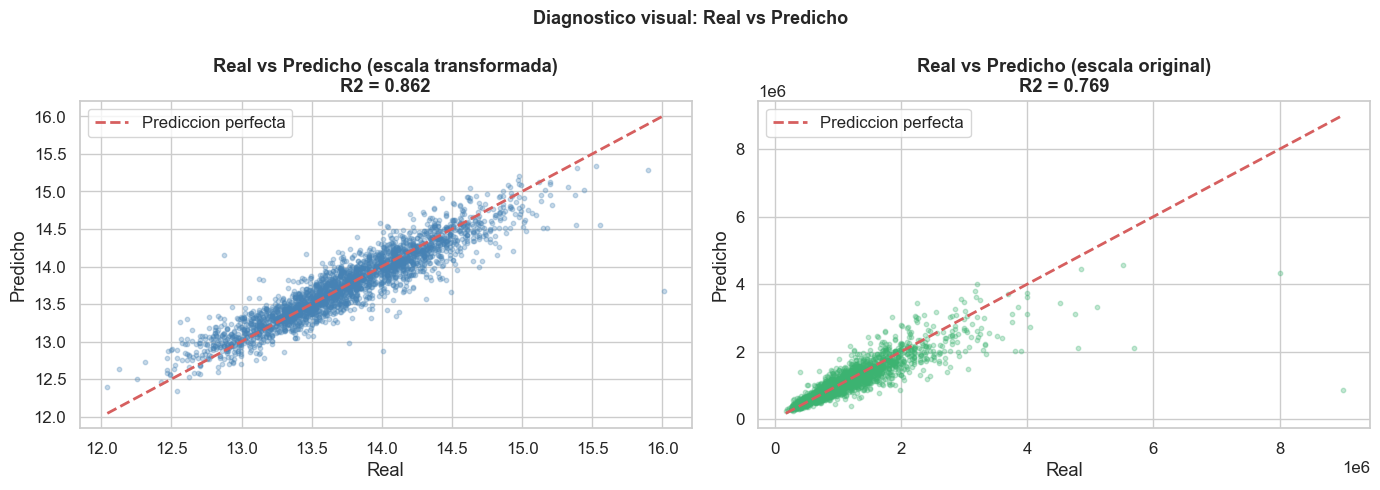

In [7]:
# ── 3b. Grafico: Real vs Predicho ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala transformada
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Prediccion perfecta')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')
axes[0].set_title(f'Real vs Predicho (escala transformada)\nR2 = {r2_test:.3f}', fontweight='bold')
axes[0].legend()

# Escala original
axes[1].scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10, color='mediumseagreen')
min_v2, max_v2 = min(y_test_orig.min(), y_pred_orig.min()), max(y_test_orig.max(), y_pred_orig.max())
axes[1].plot([min_v2, max_v2], [min_v2, max_v2], 'r--', lw=2, label='Prediccion perfecta')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predicho')
axes[1].set_title(f'Real vs Predicho (escala original)\nR2 = {r2_orig:.3f}', fontweight='bold')
axes[1].legend()

plt.suptitle('Diagnostico visual: Real vs Predicho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Paso 4 — Comparacion train vs test (detectar overfitting)

El **overfitting** ocurre cuando el modelo aprende el ruido del train
y no generaliza bien a datos nuevos.

| Situacion | R2 Train | R2 Test | Diagnostico |
|---|---|---|---|
| Buen modelo | Alto | Alto (similar) | Generaliza bien |
| Overfitting | Alto | Bajo | Modelo muy complejo |
| Underfitting | Bajo | Bajo | Modelo muy simple |

> **Regla:** Un gap R2_train - R2_test > 0.15 es senal de posible overfitting.

---


── 4. Gap train vs test ─────────────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Compara las metricas R2 y RMSE entre el conjunto de entrenamiento y el
  de test para diagnosticar si el modelo esta sobreajustado (overfitting)
  o subajustado (underfitting).

POR QUE ES IMPORTANTE
  Un modelo que funciona perfectamente en train pero mal en test ha
  memorizado los datos de entrenamiento en lugar de aprender patrones
  generalizables. En produccion ese modelo fallara con datos nuevos.
  El gap entre R2_train y R2_test es el indicador clave:
  - Gap < 0.05: modelo bien balanceado
  - Gap 0.05-0.15: leve overfitting, aceptable
  - Gap > 0.15: overfitting significativo, hay que actuar
  - Gap negativo (R2_test > R2_train): sospecha de data leakage

QUE DEBEMOS ESPERAR
  - Las barras de train y test deben ser similares en altura.
  - Si la barra de train es mucho mas alta que la de test en R2,
  - el modelo esta sobreajustado. Soluciones: usar Ridge o Lasso,
  - reducir el numero de features, o agregar mas datos de entrenamiento.

=== COMPARACION TRAIN vs TEST ===
   R2 en TRAIN: 0.9309
   R2 en TEST:  0.8622
   Gap:         0.0687

   Gap aceptable (0.069). El modelo generaliza correctamente.


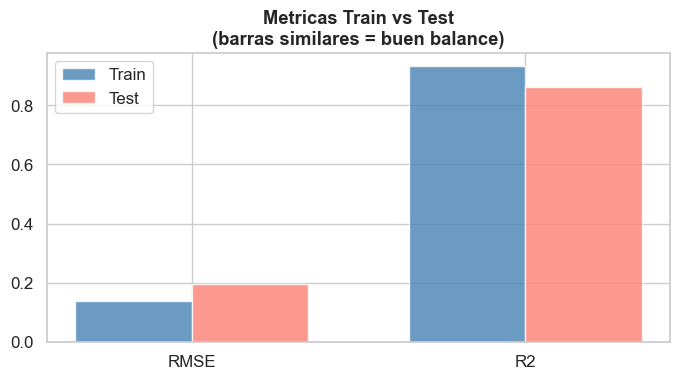

In [8]:
# ── 4. Gap train vs test ─────────────────────────────────────────────────────

gap = r2_train - r2_test

print('=== COMPARACION TRAIN vs TEST ===')
print(f'   R2 en TRAIN: {r2_train:.4f}')
print(f'   R2 en TEST:  {r2_test:.4f}')
print(f'   Gap:         {gap:.4f}')

if gap > 0.15:
    print(f'\n   AVISO: gap de {gap:.3f} indica posible overfitting.')
    print('   Opciones: regularizacion (Ridge/Lasso), menos features, mas datos.')
elif gap < 0:
    print(f'\n   AVISO: R2_test > R2_train (inusual). Revisa si hay data leakage.')
else:
    print(f'\n   Gap aceptable ({gap:.3f}). El modelo generaliza correctamente.')

# Grafico comparativo
fig, ax = plt.subplots(figsize=(7, 4))
metricas = ['RMSE', 'R2']
x = np.arange(len(metricas))
width = 0.35
ax.bar(x - width/2, [rmse_train, r2_train], width, label='Train', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [rmse_test,  r2_test],  width, label='Test',  color='salmon',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_title('Metricas Train vs Test\n(barras similares = buen balance)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Paso 5 — Validacion cruzada (5-fold)

Una sola division train/test puede dar resultados favorables o desfavorables por casualidad.

La **validacion cruzada K-fold** divide el dataset en K partes, entrena K veces
(K-1 partes para train, 1 para test) y promedia las metricas.
El resultado es mucho mas confiable que una sola evaluacion.

> El Pipeline completo se reentrena en cada fold.
> El preprocesamiento se re-aprende SOLO con el train de ese fold.

---


── 5a. Cross-validation 5-fold ──────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Ejecuta validacion cruzada de 5 folds sobre el conjunto de entrenamiento.
  El Pipeline completo se reentrena 5 veces, cada vez usando 4 partes para
  entrenar y 1 parte diferente para evaluar. Devuelve R2 y RMSE por fold.

POR QUE ES IMPORTANTE
  Una sola division train/test puede ser 'afortunada' o 'desafortunada'
  dependiendo de que filas cayeron en cada conjunto. Si por azar las
  propiedades mas caras quedaron todas en train, el R2 de test sera
  artificialmente bajo. La validacion cruzada elimina ese azar promediando
  5 evaluaciones independientes.
  Tambien es la forma correcta de comparar dos modelos: si el modelo A
  tiene R2_CV = 0.82 +/- 0.02 y el modelo B tiene R2_CV = 0.79 +/- 0.08,
  el modelo A es mejor Y mas estable.
  NOTA: n_jobs=-1 usa todos los nucleos del procesador en paralelo.
  En datasets grandes esto puede tardar varios minutos.

QUE DEBEMOS ESPERAR
  - R2 promedio cercano al R2 que calculamos en el paso 3a
  - Desviacion estandar baja (+/- < 0.05): modelo estable entre folds
  - Si el R2 de CV es mucho menor que el R2 del paso 3a, la division
    original fue 'afortunada' y el modelo real es menos bueno de lo que
    parecía. 
  - El R2 de CV es el numero mas honesto.

In [9]:
# DECISION POINT ── 5a. Cross-validation 5-fold ──────────────────────────────────────────────

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Para regresion: 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'
# Para clasificacion: 'roc_auc', 'f1', 'accuracy'
scores_r2   = cross_val_score(pipeline_final, X_train, y_train, cv=kf,
                               scoring='r2', n_jobs=-1)
scores_rmse = cross_val_score(pipeline_final, X_train, y_train, cv=kf,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
scores_rmse = -scores_rmse  # sklearn lo devuelve negativo

print('=== VALIDACION CRUZADA (5-fold) ===')
print(f'\nR2 por fold:   {scores_r2.round(4)}')
print(f'R2 promedio:   {scores_r2.mean():.4f} +/- {scores_r2.std():.4f}')
print(f'\nRMSE por fold: {scores_rmse.round(4)}')
print(f'RMSE promedio: {scores_rmse.mean():.4f} +/- {scores_rmse.std():.4f}')
print(f'\nR2 esperado en datos completamente nuevos: {scores_r2.mean():.4f}')


=== VALIDACION CRUZADA (5-fold) ===

R2 por fold:   [0.8585 0.8406 0.8661 0.8608 0.8578]
R2 promedio:   0.8568 +/- 0.0086

RMSE por fold: [0.1969 0.2077 0.1954 0.1989 0.1959]
RMSE promedio: 0.1989 +/- 0.0045

R2 esperado en datos completamente nuevos: 0.8568


── 5b. Visualizar distribucion de scores en CV ──────────────────────────────

QUE HACE ESTE BLOQUE
  Grafica el R2 y el RMSE de cada fold de la validacion cruzada
  como barras individuales con la linea del promedio superpuesta.

POR QUE ES IMPORTANTE
  El promedio solo no cuenta toda la historia. Necesitamos ver la
  dispersion entre folds para saber si el modelo es estable:
  - Barras de altura similar: el modelo aprende patrones consistentes
    independientemente de que datos ve. Es robusto y confiable.
  - Un fold con R2 muy diferente al resto: ese subconjunto de datos
    tiene caracteristicas distintas. Puede indicar que el dataset
    tiene subgrupos con comportamientos diferentes (ej: propiedades
    de lujo vs propiedades economicas que el modelo trata igual).
  - Todos los folds con R2 bajo: el modelo tiene underfitting general,
    no es un problema de datos sino del modelo o del Feature Engineering.

QUE DEBEMOS ESPERAR
  - Cinco barras de altura similar con poca dispersion alrededor de la
  - linea roja del promedio. Una variacion de +/- 0.03 en R2 entre folds
  - es normal y aceptable.

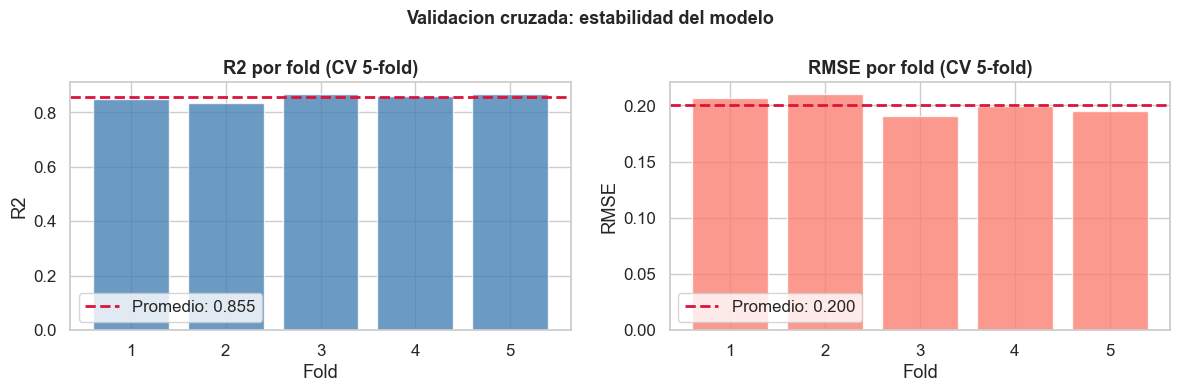

Barras muy dispares = modelo inestable. Barras similares = modelo estable.


In [10]:
# ── 5b. Visualizar distribucion de scores en CV ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 6), scores_r2, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(scores_r2.mean(), color='crimson', ls='--', lw=2,
                label=f'Promedio: {scores_r2.mean():.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R2')
axes[0].set_title('R2 por fold (CV 5-fold)', fontweight='bold')
axes[0].legend()

axes[1].bar(range(1, 6), scores_rmse, color='salmon', alpha=0.8, edgecolor='white')
axes[1].axhline(scores_rmse.mean(), color='crimson', ls='--', lw=2,
                label=f'Promedio: {scores_rmse.mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE por fold (CV 5-fold)', fontweight='bold')
axes[1].legend()

plt.suptitle('Validacion cruzada: estabilidad del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Barras muy dispares = modelo inestable. Barras similares = modelo estable.')


---
## Paso 6 — Analisis de residuos

Los **residuos** son la diferencia entre el valor real y el predicho:
`residuo = real - predicho`

Si el modelo es bueno, los residuos deben:
- Estar centrados en 0 (sin sesgo sistematico)
- Tener distribucion aproximadamente normal
- No mostrar patron al graficarse vs predicciones (homocedasticidad)

Si los residuos muestran un patron (curva, embudo), el modelo esta fallando
en capturar alguna relacion en los datos.

---


── 6a. Calcular residuos ─────────────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Calcula los residuos (real - predicho), sus estadisticas descriptivas
  y aplica el test de Shapiro-Wilk para verificar si tienen distribucion
  normal.

POR QUE ES IMPORTANTE
  Los residuos son la 'firma' de lo que el modelo no pudo aprender.
  Si tienen distribucion normal centrada en cero, significa que los
  errores son aleatorios: el modelo capturo todo el patron sistematico
  y solo queda ruido imposible de predecir.
  Si los residuos NO son normales o su media es distinta de cero, el
  modelo esta dejando patrones sin capturar: hay relaciones no lineales,
  variables importantes que faltan, o el modelo es demasiado simple.
  El test Shapiro-Wilk formaliza esto estadisticamente:
  - p-valor > 0.05: los residuos son normales (modelo correcto)
  - p-valor < 0.05: los residuos NO son normales (hay algo que mejorar)

QUE DEBEMOS ESPERAR
  - Media de residuos muy cercana a 0 (idealmente < 0.01 en escala log)
  - p-valor de Shapiro-Wilk > 0.05
  - En datasets grandes (> 5000 filas) Shapiro-Wilk casi siempre da
  p-valor < 0.05 aunque los residuos sean visualmente normales. 
  - En ese caso confía mas en el QQ-Plot del bloque siguiente que en el test.

In [10]:
# ── 6a. Calcular residuos ─────────────────────────────────────────────────────

residuos = y_test.values - y_pred

print('=== ANALISIS DE RESIDUOS ===')
print(f'  Media de residuos  : {residuos.mean():.4f}  (deberia ser ~0)')
print(f'  Desv. estandar     : {residuos.std():.4f}')
print(f'  Maximo             : {residuos.max():.4f}')
print(f'  Minimo             : {residuos.min():.4f}')

# Test de normalidad de Shapiro-Wilk
muestra = np.random.choice(residuos, size=min(5000, len(residuos)), replace=False)
stat, p_valor = stats.shapiro(muestra)
print(f'\nTest Shapiro-Wilk (normalidad):')
print(f'   p-valor: {p_valor:.4f}')
if p_valor > 0.05:
    print('   Residuos aproximadamente normales (p > 0.05)')
else:
    print('   Residuos NO normales (p < 0.05) -> puede indicar relaciones no capturadas')


=== ANALISIS DE RESIDUOS ===
  Media de residuos  : 0.0019  (deberia ser ~0)
  Desv. estandar     : 0.1964
  Maximo             : 2.3409
  Minimo             : -1.2792

Test Shapiro-Wilk (normalidad):
   p-valor: 0.0000
   Residuos NO normales (p < 0.05) -> puede indicar relaciones no capturadas


── 6b. Graficos de residuos ─────────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Genera cuatro graficos para diagnosticar visualmente los residuos
  desde diferentes angulos.

POR QUE ES IMPORTANTE
  Cada grafico revela un tipo diferente de problema:

  GRAFICO 1 — Residuos vs Predichos (homocedasticidad)
  Diagnostica si el error es constante en todo el rango de predicciones.
  - Nube horizontal sin patron: error uniforme. Modelo correcto.
  - Forma de embudo (error crece con el valor predicho): el modelo
    falla mas en propiedades caras que en baratas. Soluccion: transformar
    el target con log si aun no lo hiciste.
  - Curva en U o arco: hay relacion no lineal que el modelo no capturo.
    Solucion: agregar features polinomiales o usar modelo no lineal.

  GRAFICO 2 — Distribucion de residuos (normalidad)
  Diagnostica si los errores tienen distribucion normal.
  - Campana centrada en 0: errores aleatorios. Ideal.
  - Campana desplazada a la derecha o izquierda: sesgo sistematico.
    El modelo sobreestima o subestima consistentemente.
  - Dos picos (bimodal): el dataset tiene dos grupos con comportamientos
    muy distintos que el modelo trata como uno solo.

  GRAFICO 3 — QQ-Plot (normalidad formal)
  Compara los cuantiles de los residuos contra una normal teorica.
  - Puntos sobre la linea roja: residuos normales. Ideal.
  - Colas que se alejan de la linea: distribucion con colas pesadas.
    Hay errores muy grandes que ocurren mas frecuentemente de lo esperado.

  GRAFICO 4 — Residuos vs Reales
  Diagnostica si el error es sistematico en funcion del valor real.
  - Nube horizontal: error uniforme en todo el rango. Ideal.
  - El error es mayor para valores reales altos: el modelo subestima
    las propiedades de alto valor (problema comun en inmobiliaria).

QUE DEBEMOS ESPERAR
  - Los cuatro graficos deben mostrar nubes o curvas sin patron sistematico.
  - Cualquier patron visible (embudo, curva, desplazamiento) es una pista de donde mejorar el modelo en la siguiente iteracion.


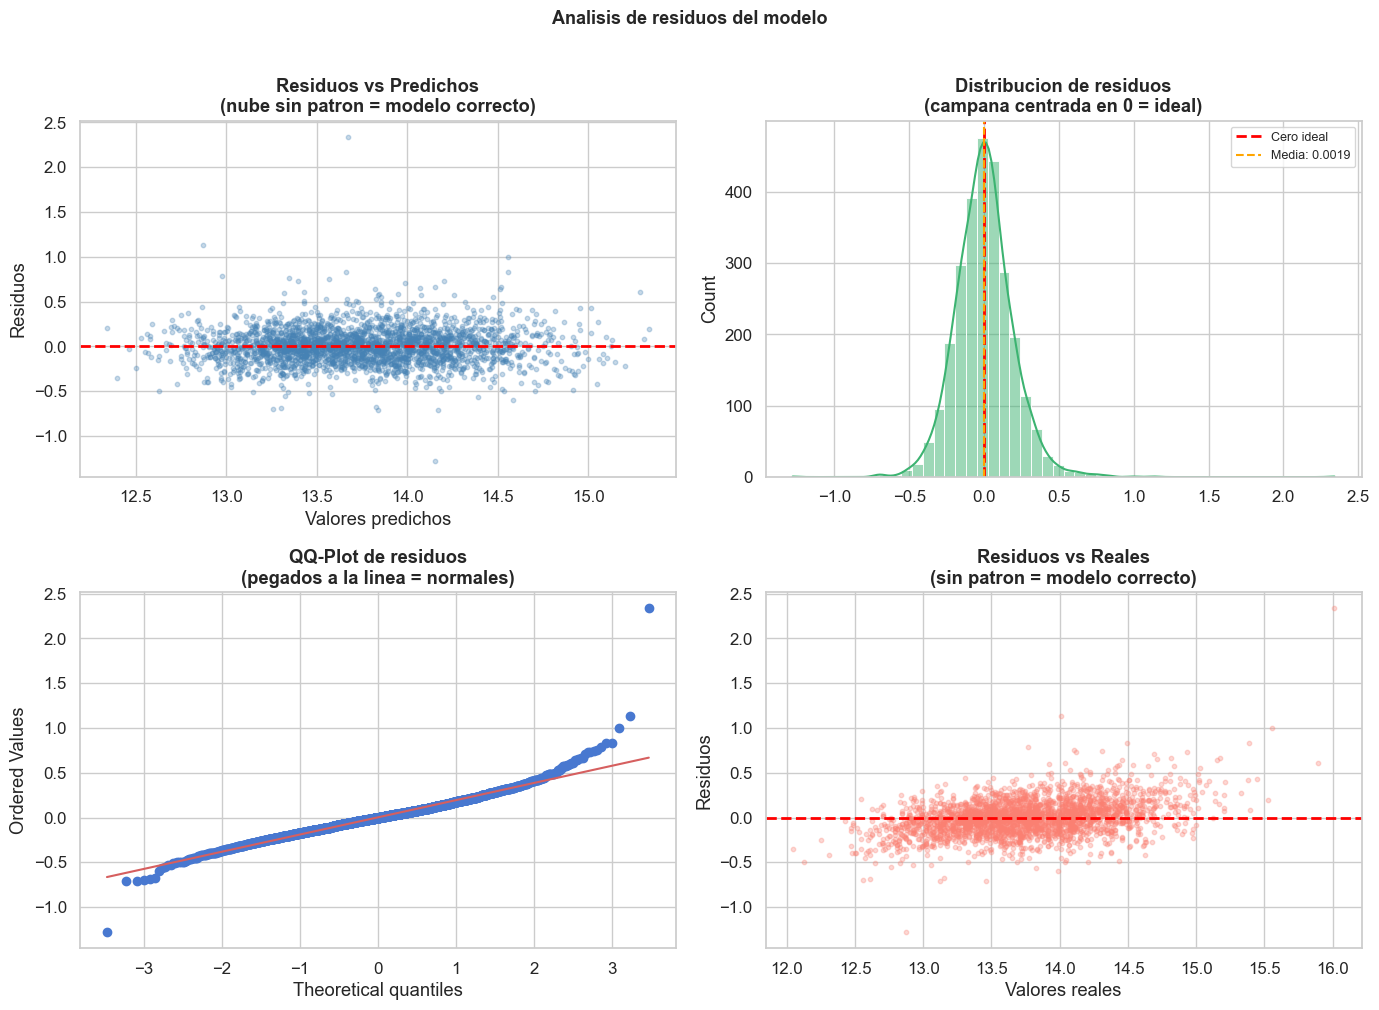

In [11]:
# ── 6b. Graficos de residuos ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Predicciones
axes[0,0].scatter(y_pred, residuos, alpha=0.3, s=10, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', lw=2)
axes[0,0].set_xlabel('Valores predichos')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs Predichos\n(nube sin patron = modelo correcto)', fontweight='bold')

# 2. Distribucion de residuos
sns.histplot(residuos, ax=axes[0,1], kde=True, color='mediumseagreen', bins=50)
axes[0,1].axvline(0, color='red', ls='--', lw=2, label='Cero ideal')
axes[0,1].axvline(residuos.mean(), color='orange', ls='--', lw=1.5,
                  label=f'Media: {residuos.mean():.4f}')
axes[0,1].set_title('Distribucion de residuos\n(campana centrada en 0 = ideal)', fontweight='bold')
axes[0,1].legend(fontsize=9)

# 3. QQ-Plot de residuos
stats.probplot(residuos, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ-Plot de residuos\n(pegados a la linea = normales)', fontweight='bold')

# 4. Residuos vs Reales
axes[1,1].scatter(y_test.values, residuos, alpha=0.3, s=10, color='salmon')
axes[1,1].axhline(0, color='red', linestyle='--', lw=2)
axes[1,1].set_xlabel('Valores reales')
axes[1,1].set_ylabel('Residuos')
axes[1,1].set_title('Residuos vs Reales\n(sin patron = modelo correcto)', fontweight='bold')

plt.suptitle('Analisis de residuos del modelo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Paso 7 — Importancia de features

La importancia de features nos dice que variables tienen mas impacto en las predicciones.
Ayuda a interpretar el modelo, detectar leakage y guiar el Feature Engineering.

---


── 7a. Obtener importancia segun el tipo de modelo ─────────────────────────

QUE HACE ESTE BLOQUE
  Extrae la importancia de cada feature del modelo entrenado y la
  presenta en una tabla ordenada de mayor a menor impacto.
  El metodo de extraccion depende del tipo de modelo:
  - Modelos lineales (LinearRegression, Ridge, Lasso): usa los coeficientes.
    Un coeficiente grande significa que esa variable mueve mucho el target.
  - Modelos de arboles (RandomForest, GradientBoosting): usa feature_importances_,
    que mide cuanto mejora cada feature la pureza de los nodos del arbol.

POR QUE ES IMPORTANTE
  La importancia de features responde tres preguntas criticas:
  1. INTERPRETACION: que variables explican el Target segun el modelo? 
    Esto permite validar con expertos del dominio si tiene sentido de negocio.
  2. DETECCION DE LEAKAGE: si una variable sorpresivamente trivial
     aparece como la mas importante, puede indicar data leakage.
     Ejemplo: si 'fecha_registro' es la feature mas importante en un
     modelo de precios, algo esta mal.
  3. GUIA PARA EL FE: las features con importancia cercana a cero son
     candidatas a eliminar en la proxima iteracion del Feature Engineering.
     Las features mas importantes son las que vale la pena enriquecer
     con nuevas transformaciones o interacciones.

QUE DEBEMOS ESPERAR
  - Una tabla con las 15 features mas importantes ordenadas de mayor a menor.
  - Para modelos lineales los coeficientes tienen signo: positivo significa
  - que al aumentar esa variable el Traget sube, negativo que baja.
  - Si aparecen variables de indicadores de nulos como las mas importantes, algo puede estar mal en el Feature Engineering.


In [12]:
# ── Mapeo directo de feature_N a nombre real ──────────────────────────────────
# Tu pipeline tiene todas las columnas en el transformer 'num' porque el OHE
# ya se aplico en el FE. Los nombres estan directamente en preprocessor.transformers_
# No necesitamos get_feature_names_out(), solo leemos las columnas de cada transformer.

preprocessor = pipeline_final.named_steps['preprocesamiento']
modelo        = pipeline_final.named_steps['modelo']
nombre_modelo = type(modelo).__name__

# ── Reconstruir lista de nombres en el orden exacto que ve el modelo ──────────
feature_names_mapeados = []

for nombre_trans, transformer, columnas in preprocessor.transformers_:
    if nombre_trans == 'remainder':
        continue
    if isinstance(columnas, list):
        feature_names_mapeados.extend(columnas)
    else:
        feature_names_mapeados.append(columnas)

print(f'Total features mapeadas : {len(feature_names_mapeados)}')
print(f'Nombres: {feature_names_mapeados}')

Total features mapeadas : 20
Nombres: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Propertycount', 'CouncilArea_era_nulo', '+3_rooms', 'Date_ano', 'Date_mes', 'Date_dia_semana', 'Type_t', 'Type_u', 'Method_S', 'Method_SP', 'Method_VB', 'Regionname_Northern Metropolitan', 'Regionname_South-Eastern Metropolitan', 'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan']


In [13]:
# ── 7a. Importancia de features con nombres reales ────────────────────────────

# Verificar que el numero de nombres coincide con el numero de coeficientes
if hasattr(modelo, 'coef_'):
    coef = modelo.coef_
    n    = min(len(feature_names_mapeados), len(coef))

    if len(feature_names_mapeados) != len(coef):
        print(f'AVISO: nombres={len(feature_names_mapeados)}, coeficientes={len(coef)}')
        print('Se usaran los primeros N coincidentes.')

    importancias = pd.DataFrame({
        'feature':     feature_names_mapeados[:n],
        'importancia': np.abs(coef[:n]),
        'coeficiente': coef[:n],
        'efecto':      ['+ Positivo' if v > 0 else '- Negativo' for v in coef[:n]]
    }).sort_values('importancia', ascending=False).reset_index(drop=True)

    importancias.index += 1
    print(f'\nTop 15 features mas importantes — {nombre_modelo}:')
    display(
        importancias.head(15)
        .style
        .background_gradient(subset=['importancia'], cmap='Blues')
        .applymap(
            lambda v: 'color: green' if '+' in str(v) else 'color: crimson',
            subset=['efecto']
        )
        .format({'importancia': '{:.4f}', 'coeficiente': '{:.4f}'})
    )

elif hasattr(modelo, 'feature_importances_'):
    imp = modelo.feature_importances_
    n   = min(len(feature_names_mapeados), len(imp))

    importancias = pd.DataFrame({
        'feature':       feature_names_mapeados[:n],
        'importancia':   imp[:n],
        'importancia_%': (imp[:n] / imp[:n].sum() * 100).round(2)
    }).sort_values('importancia', ascending=False).reset_index(drop=True)

    importancias.index += 1
    print(f'\nTop 15 features mas importantes — {nombre_modelo}:')
    display(
        importancias.head(15)
        .style
        .background_gradient(subset=['importancia'], cmap='Greens')
        .format({'importancia': '{:.4f}', 'importancia_%': '{:.1f}%'})
    )

else:
    print('Este modelo no expone importancia directamente.')
    print('Usa permutation_importance de sklearn para cualquier modelo.')



Top 15 features mas importantes — GradientBoostingRegressor:


,feature,importancia,importancia_%
1,Type_u,0.2088,20.9%
2,Distance,0.1727,17.3%
3,Regionname_Southern Metropolitan,0.1622,16.2%
4,Landsize,0.1010,10.1%
5,Rooms,0.1009,10.1%
6,+3_rooms,0.0596,6.0%
7,Propertycount,0.0500,5.0%
8,Bathroom,0.0486,4.9%
9,Regionname_Western Metropolitan,0.0193,1.9%
10,Regionname_Northern Metropolitan,0.0185,1.9%


── 7b. Grafico de importancia ────────────────────────────────────────────────

QUE HACE ESTE BLOQUE
  Grafica las 15 features mas importantes como barras horizontales.
  Para modelos lineales las barras tienen signo (positivo/negativo).
  Para modelos de arboles todas las barras son positivas.

POR QUE ES IMPORTANTE
  La tabla del bloque anterior tiene precision numerica pero es dificil
  de leer de un vistazo. El grafico permite identificar rapidamente:
  - Que features dominan el modelo (barras muy largas)
  - Si hay un grupo pequeno de features que concentra casi toda la
    importancia (situacion comun: el 20% de features explica el 80%)
  - Si la importancia cae suavemente o hay un corte brusco que sugiere
    un numero natural de features a conservar
  - Para modelos lineales el color indica la direccion del efecto:
    azul = aumentar esa variable sube el precio, rojo = lo baja.

QUE DEBEMOS ESPERAR
  - Un grafico con barras de longitud decreciente de arriba hacia abajo.
  - Las features mas importantes apareceran en la parte superior.
  - Si TODAS las barras tienen longitudes similares, el modelo distribuye
    el peso uniformemente y ninguna feature domina, lo cual es inusual
    y puede indicar que el modelo no encontro patrones claros.


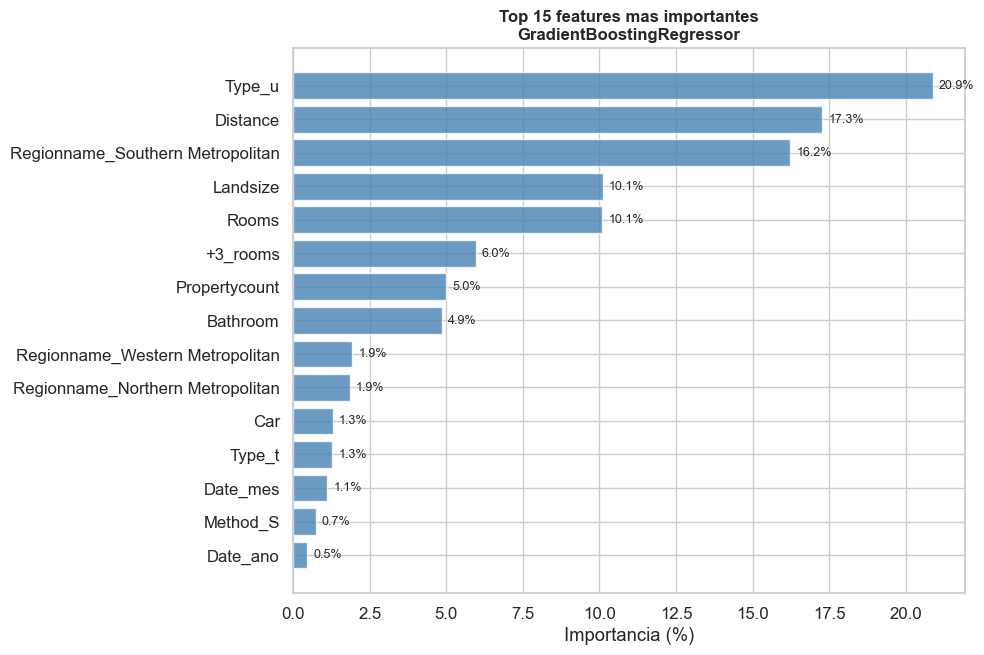

In [14]:
# ── 7b. Grafico de importancia ───────────────────────────────────────────────────────────────────
top15 = importancias.head(15)
fig, ax = plt.subplots(figsize=(10, max(4, len(top15) * 0.45)))

if 'coeficiente' in top15.columns:
    colores = ['crimson' if v < 0 else 'steelblue' for v in top15['coeficiente']]
    ax.barh(top15['feature'], top15['coeficiente'],
            color=colores, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Coeficiente  (azul = sube precio | rojo = baja precio)')
else:
    ax.barh(top15['feature'], top15['importancia_%'],
            color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Importancia (%)')
    for i, (val, feat) in enumerate(zip(top15['importancia_%'], top15['feature'])):
        ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_title(f'Top 15 features mas importantes\n{nombre_modelo}',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Paso 8 — Conclusiones y Recomendaciones

QUE DEBEMOS ESPERAR
  Un reporte con 6 secciones: metricas transformadas, metricas originales,
  diagnostico de overfitting, validacion cruzada, residuos y recomendaciones.
  Las recomendaciones deben guiar el siguiente paso concreto:
  - si R2 < 0.5 -> volver al FE
  - si gap > 0.15 -> regularizar el modelo
  - si std_cv > 0.05 -> cambiar a modelo mas robusto
  - si todo esta bien -> ajustar hiperparametros o comparar con otros modelos

---


In [15]:
# ── 8. Resumen completo de evaluacion ────────────────────────────────────────

sep  = '-' * 70
sep2 = '=' * 70

print(sep2)
print('  RESUMEN DE EVALUACION DEL MODELO')
print(f'  Modelo: {type(pipeline_final.named_steps["modelo"]).__name__}')
print(f'  Target: {TARGET_COL}')
print(sep2)

print(f'\n1. METRICAS EN TEST (escala transformada)')
print(sep)
print(f'   RMSE  : {rmse_test:.4f}')
print(f'   MAE   : {mae_test:.4f}')
print(f'   R2    : {r2_test:.4f}  ->  el modelo explica el {r2_test*100:.1f}% de la varianza')

print(f'\n2. METRICAS EN ESCALA ORIGINAL')
print(sep)
print(f'   RMSE  : {rmse_orig:,.0f}')
print(f'   MAE   : {mae_orig:,.0f}')
print(f'   MAPE  : {mape_orig*100:.1f}%  ->  error promedio porcentual')
print(f'   R2    : {r2_orig:.4f}')

print(f'\n3. OVERFITTING (gap train-test)')
print(sep)
print(f'   R2 train : {r2_train:.4f}')
print(f'   R2 test  : {r2_test:.4f}')
print(f'   Gap      : {gap:.4f}  ->  {"AVISO: revisar overfitting" if gap > 0.15 else "OK"}')

print(f'\n4. VALIDACION CRUZADA (5-fold)')
print(sep)
print(f'   R2 promedio  : {scores_r2.mean():.4f} +/- {scores_r2.std():.4f}')
print(f'   RMSE promedio: {scores_rmse.mean():.4f} +/- {scores_rmse.std():.4f}')

print(f'\n5. DIAGNOSTICO DE RESIDUOS')
print(sep)
if abs(residuos.mean()) < 0.01:
    print('   Sin sesgo sistematico (media de residuos ~ 0)')
else:
    print(f'   AVISO: sesgo en residuos (media={residuos.mean():.4f})')

print(f'\n6. RECOMENDACIONES')
print(sep)
if r2_test < 0.5:
    print('   R2 bajo: considera mas feature engineering, modelos no lineales o mas datos.')
elif gap > 0.15:
    print('   Overfitting: prueba Ridge/Lasso, reduce features o usa regularizacion.')
elif scores_r2.std() > 0.05:
    print('   Alta varianza en CV: modelo inestable. Prueba RF o XGBoost.')
else:
    print('   El modelo tiene buen desempeno. Siguientes pasos:')
print('   a) Comparar con otros modelos (RandomForest, XGBoost)')
print('   b) Ajustar hiperparametros (GridSearchCV / RandomizedSearchCV)')
print('   c) Reportar MAPE al cliente (mas interpretable que RMSE)')
print('   d) Analizar casos donde el modelo falla mas (errores grandes)')

print()
print(sep2)
print('  Evaluacion completada.')
print(sep2)


  RESUMEN DE EVALUACION DEL MODELO
  Modelo: GradientBoostingRegressor
  Target: Price_log

1. METRICAS EN TEST (escala transformada)
----------------------------------------------------------------------
   RMSE  : 0.1964
   MAE   : 0.1447
   R2    : 0.8622  ->  el modelo explica el 86.2% de la varianza

2. METRICAS EN ESCALA ORIGINAL
----------------------------------------------------------------------
   RMSE  : 314,994
   MAE   : 165,370
   MAPE  : 14.5%  ->  error promedio porcentual
   R2    : 0.7692

3. OVERFITTING (gap train-test)
----------------------------------------------------------------------
   R2 train : 0.9309
   R2 test  : 0.8622
   Gap      : 0.0687  ->  OK

4. VALIDACION CRUZADA (5-fold)
----------------------------------------------------------------------
   R2 promedio  : 0.8568 +/- 0.0086
   RMSE promedio: 0.1989 +/- 0.0045

5. DIAGNOSTICO DE RESIDUOS
----------------------------------------------------------------------
   Sin sesgo sistematico (media de res